In [ ]:
1. Introduction
    In Task 3, the goal is to come up with some hypotheses before diving into deep data exploration or building any 
    machine learning models. This matters because it pushes us to lay out our expectations about which variables might
    affect income and how. Instead of just poking around in the data without a plan, having clear hypotheses gives us
    a sense of direction. It also makes sure that whatever we find later actually makes sense and is easier to explain.

2. Objective of Hypothesis Generation
    we want to come up with clear, structured hypotheses for the Adult Census Income dataset.
    These are statements about how we think the input variables connect to the target variable.
    Later, we’ll check if our guesses hold up using exploratory data analysis and machine learning.

3. Target Variable
    Here, the main thing we’re looking at is income. People get sorted into two groups: those making $50,000 a year or less, and those
    who pull in more than $50,000. Since we’re just picking between two categories, this is a binary classification problem.

4. Primary Hypothesis
    Null Hypothesis (H₀):  
     A person’s age, background, education, and job details don’t really affect which income category they fall into.
    Alternative Hypothesis (H₁):  
     A person’s background, education, and work history actually play a big part in whether they make more than $50,000 a year.
    These two ideas set the stage for how we’ll look at the data and what we’ll focus on.

5. Feature-Level Hypotheses
    Let’s dig deeper into what actually affects income. Instead of looking at one big question, it makes sense to break things
    down by feature. Each section here zooms in on its own group of factors.
   5.1  Education-Based Hypotheses
         Education says a lot — it shows someone’s skills, qualifications, and usually opens doors to better jobs. It just makes
         sense that education shapes how much people earn.
       - People with more education are more likely to make over $50,000.
       - When education_num goes up, income tends to go up too.
         We’ll test these ideas by comparing how much people earn in different education groups, and by looking at education_num scores.
   5.2  Age and Experience Hypotheses
         Age often stands in for experience. The longer someone’s been working, the more they usually make.
       - Income goes up with age — at least for most working adults.
       - Younger people, who don’t have much experience yet, usually don’t earn more than $50,000.
         But income doesn’t always keep rising forever. At some point, as people get older, it can level off.
         The connection between age and income isn’t always a straight line.
   5.3  Work Hours Hypotheses
         How many hours you work each week really shapes your paycheck. It also says a lot about whether you’re working part-time or full-time.
	     People who put in longer hours usually end up earning over $50,000. On the other hand, part-time workers tend to make $50,000 or less.
   5.4 Occupation and Workclass Hypotheses
         Not all jobs pay the same—some fields just offer bigger paychecks. If you’re in a professional or managerial role, you’re more likely to earn          over $50,000. Income also changes depending on whether you work in the private sector, for the government, or if you’re self-employed.
   5.5 Marital Status and Relationship Hypotheses
        Your home life and relationship status can shape your career and your income over time. People who are married tend to have steadier jobs,
	    work more hours, and, yeah, are more likely to make over $50,000. Relationship categories often come with clear differences in income.
   5.6 Capital Gain and Capital Loss Hypotheses
        Capital gains and losses are tied to investment activity and therefore often reflect higher overall wealth. Individuals who report any capital         gains are significantly more likely to earn above $50,000, making capital gain one of the strongest indicators of high income.
   5.7 Demographic and Fairness Hypotheses
        Demographics like sex and race can impact how income is spread out. These gaps usually say more about society and history than about 
	    individual skills. Income isn’t split the same way between men and women, or among different racial groups. Whenever we look at these
	    differences, we need to be thoughtful and fair about what they really mean.
   5.8 Census Weight (fnlwgt) Hypotheses
        The fnlwgt variable just shows how the census samples people; it doesn’t measure income. It probably won’t help much with predicting who
	    earns more, but we’ll test it out during modeling.
6. Role of Hypotheses in the ML Workflow
     Hypotheses provide direction throughout exploratory data analysis and model development. They help identify which relationships to
	 investigate, which features may require transformation, and how to interpret the results produced by the model.
7. Conclusion
     Task 3 establishes clear expectations for patterns within the Adult Census Income dataset. Defining hypotheses in advance keeps the analysis
	 focused and logically structured, allowing insights to be evaluated and refined as modeling progresses.	

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]
adult_df=pd.read_csv("adult.data",
    names=columns,
    header=None,
    sep=",",
    skipinitialspace=True
)
# Clean target (in case some sources include a trailing '.')
adult_df["income"] = adult_df["income"].str.replace(".", "", regex=False).str.strip()

print("Shape:", adult_df.shape)
print("\nIncome counts:\n", adult_df["income"].value_counts())


Shape: (32561, 15)

Income counts:
 income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [4]:
#Helper: plot “% earning >50K” by a categorical feature
#This is a clear way to validate many hypotheses.

def plot_high_income_rate_by_category(data, col, min_count=50, top_n=15, title=None):
    """Plot proportion of >50K within each category in `col`."""
    tmp = data[[col, "income"]].dropna().copy()
    counts = tmp[col].value_counts()
    keep = counts[counts >= min_count].index
    tmp = tmp[tmp[col].isin(keep)]

    rate = tmp.groupby(col)["income"].apply(lambda s: (s == ">50K").mean())

    # Keep top_n categories by sample size for readability
    top_categories = tmp[col].value_counts().head(top_n).index
    rate = rate.loc[[c for c in rate.index if c in top_categories]].sort_values()

    plt.figure(figsize=(10, 6))
    plt.barh(rate.index, rate.values)
    plt.xlabel("Proportion earning >50K")
    plt.ylabel(col.replace("_", " ").title())
    plt.title(title or f"Proportion of >50K earners by {col}")
    plt.xlim(0, 1)
    plt.grid(axis="x", alpha=0.3)
    plt.show()



## 1) Education-Based Hypotheses


In [ ]:
Education vs Income
H0: Income category is independent of education level.
H1: Income category depends on education level.
Why: Education is commonly linked to earning potential.

In [5]:
# Quick cross-tab example (Education vs Income) - not a statistical test yet
pd.crosstab(adult_df["education"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
education,,
10th,0.933548,0.066452
11th,0.948936,0.051064
12th,0.923788,0.076212
1st-4th,0.964286,0.035714
5th-6th,0.951952,0.048048
7th-8th,0.938080,0.061920
9th,0.947471,0.052529
Assoc-acdm,0.751640,0.248360
Assoc-voc,0.738784,0.261216


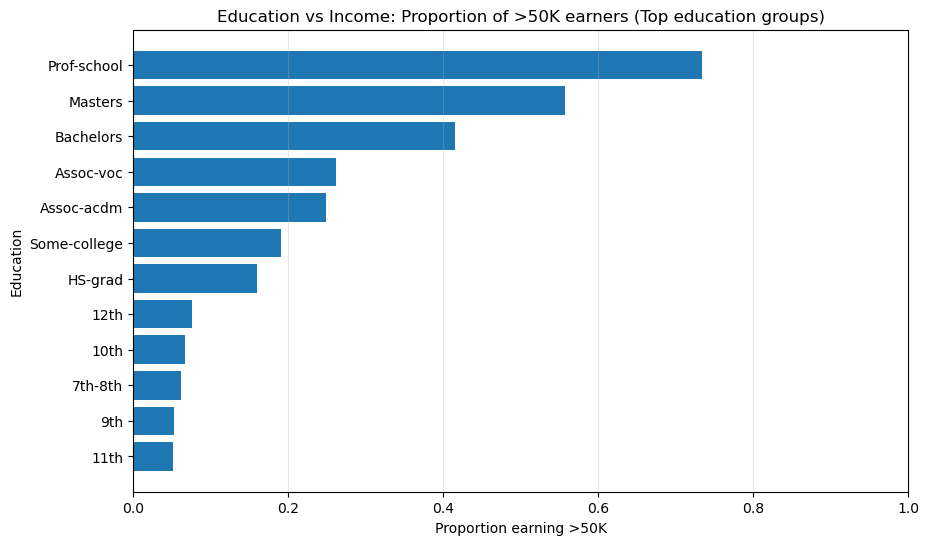

In [6]:
plot_high_income_rate_by_category(
    adult_df, "education", min_count=100, top_n=12,
    title="Education vs Income: Proportion of >50K earners (Top education groups)"
)

In [ ]:
1) Education-Based Hypotheses:-
The plots show a clear relationship between education and income. Individuals with higher education levels, such as Bachelor’s, Master’s,
and Doctorate degrees, have a noticeably higher proportion of earners above $50,000. 	 

In [ ]:
education_num vs income
H0: Income category is independent of education level (education_num).
H1: Income category depends on education level (education_num).
Why: Education_num reflects years of education completed, and higher education typically leads to better-paying jobs, increasing the likelihood of
higher income.    

In [60]:
# Quick cross-tab example (education_num vs Income) - not a statistical test yet
pd.crosstab(adult_df["education_num"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
education_num,,
1,1.000000,0.000000
2,0.964286,0.035714
3,0.951952,0.048048
4,0.938080,0.061920
5,0.947471,0.052529
6,0.933548,0.066452
7,0.948936,0.051064
8,0.923788,0.076212
9,0.840491,0.159509


C:\Users\sndrp\AppData\Local\Temp\ipykernel_28852\413877083.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("edu_bin")["income"].apply(lambda s: (s == ">50K").mean())


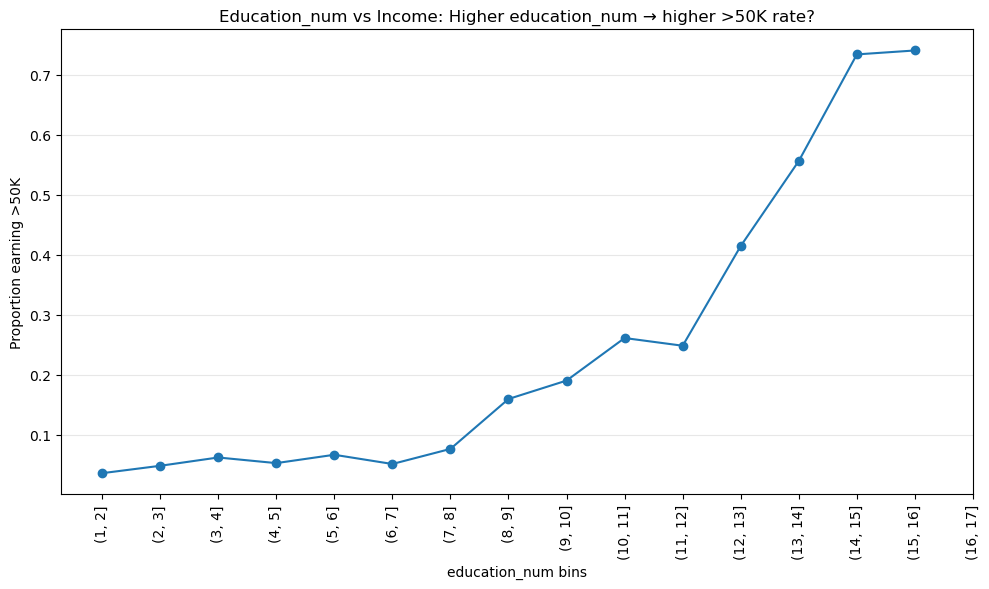

In [14]:
tmp = adult_df[["education_num", "income"]].dropna().copy()
tmp["edu_bin"] = pd.cut(tmp["education_num"], bins=range(int(tmp["education_num"].min()), int(tmp["education_num"].max()) + 2))
rate = tmp.groupby("edu_bin")["income"].apply(lambda s: (s == ">50K").mean())

plt.figure(figsize=(10, 6))
plt.plot(range(len(rate)), rate.values, marker="o")
plt.xticks(range(len(rate)), [str(b) for b in rate.index], rotation=90)
plt.ylabel("Proportion earning >50K")
plt.xlabel("education_num bins")
plt.title("Education_num vs Income: Higher education_num → higher >50K rate?")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
The trend using education_num also shows that as the numeric education level increases, the likelihood of earning more than $50,000 consistently rises.

Conclusion: Education is a strong predictor of income, and both education and education_num are meaningful features for modeling.    


## 2) Age and Experience Hypotheses


In [ ]:
age vs income
H0: Income category is independent of age.
H1: Income category depends on age.
Why: Age is often related to work experience, career progression, and skill accumulation, which can affect earning potential and income levels.    

In [62]:
# Quick cross-tab example (education_num vs Income) - not a statistical test yet
pd.crosstab(adult_df["age"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
age,,
17,1.000000,0.000000
18,1.000000,0.000000
19,0.997191,0.002809
20,1.000000,0.000000
21,0.995833,0.004167
22,0.983007,0.016993
23,0.986317,0.013683
24,0.961153,0.038847
25,0.936980,0.063020


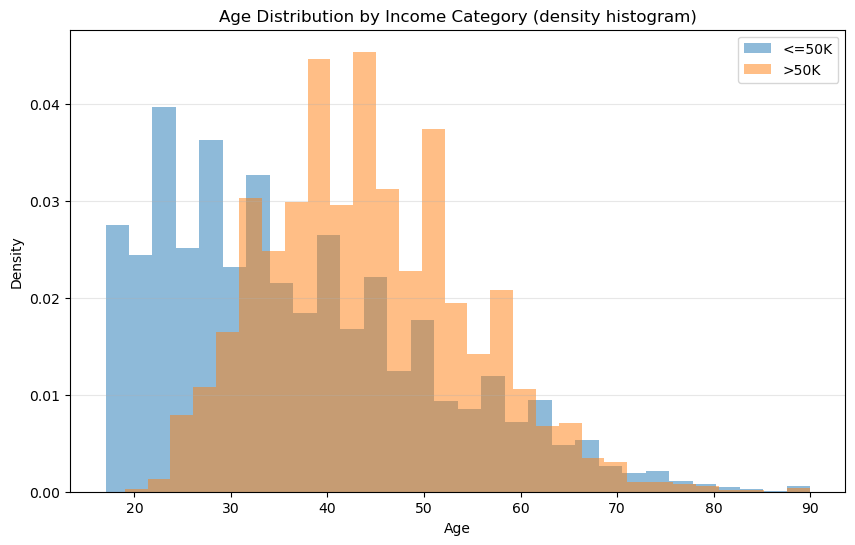

In [42]:
plt.figure(figsize=(10, 6))
for label in ["<=50K", ">50K"]:
    ages =  adult_df.loc[ adult_df["income"] == label, "age"].dropna()
    plt.hist(ages, bins=30, density=True, alpha=0.5, label=label)

plt.title("Age Distribution by Income Category (density histogram)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()


C:\Users\sndrp\AppData\Local\Temp\ipykernel_42636\3657129707.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("age_group")["income"].apply(lambda s: (s == ">50K").mean())


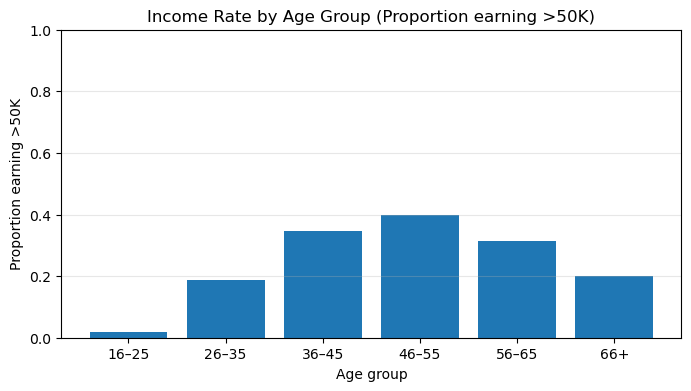

In [9]:
tmp = adult_df[["age", "income"]].dropna().copy()
age_bins = [15, 25, 35, 45, 55, 65, 100]
age_labels = ["16–25", "26–35", "36–45", "46–55", "56–65", "66+"]
tmp["age_group"] = pd.cut(tmp["age"], bins=age_bins, labels=age_labels, right=True)

rate = tmp.groupby("age_group")["income"].apply(lambda s: (s == ">50K").mean())

plt.figure(figsize=(8 , 4))
plt.bar(rate.index.astype(str), rate.values)
plt.ylim(0, 1)
plt.title("Income Rate by Age Group (Proportion earning >50K)")
plt.xlabel("Age group")
plt.ylabel("Proportion earning >50K")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
2) Age and Experience Hypotheses:-
The age distribution plot reveals that higher-income earners are concentrated in middle working ages rather than at very young or very old ages.
Younger individuals are more likely to earn $50,000 or less, while income rates increase through mid-career stages and then begin to level off.

Conclusion: Age has a non-linear relationship with income, supporting the idea that experience increases earnings up to a certain point.


## 3) Work Hours Hypotheses


In [ ]:
 Hours per Week vs Income
H0: Mean hours worked per week is the same for <=50K and >50K.
H1: Mean hours worked per week differs between <=50K and >50K.
Why: Higher earning jobs may involve longer work hours.

In [50]:
# Quick cross-tab example (Hours per Week vs Income) - not a statistical test yet
pd.crosstab(adult_df["hours_per_week"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
hours_per_week,,
1,0.900000,0.100000
2,0.750000,0.250000
3,0.974359,0.025641
4,0.944444,0.055556
5,0.883333,0.116667
6,0.875000,0.125000
7,0.846154,0.153846
8,0.924138,0.075862
9,0.944444,0.055556


C:\Users\sndrp\AppData\Local\Temp\ipykernel_42636\4076802251.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)


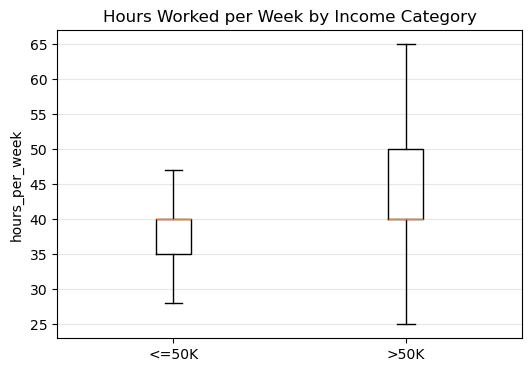

In [7]:
tmp = adult_df[["hours_per_week", "income"]].dropna().copy()

plt.figure(figsize=(6, 4))
data = [tmp.loc[tmp["income"] == "<=50K", "hours_per_week"],
        tmp.loc[tmp["income"] == ">50K", "hours_per_week"]]
plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)
plt.title("Hours Worked per Week by Income Category")
plt.ylabel("hours_per_week")
plt.grid(axis="y", alpha=0.3)
plt.show()


C:\Users\sndrp\AppData\Local\Temp\ipykernel_28852\2899745785.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("hours_group")["income"].apply(lambda s: (s == ">50K").mean())


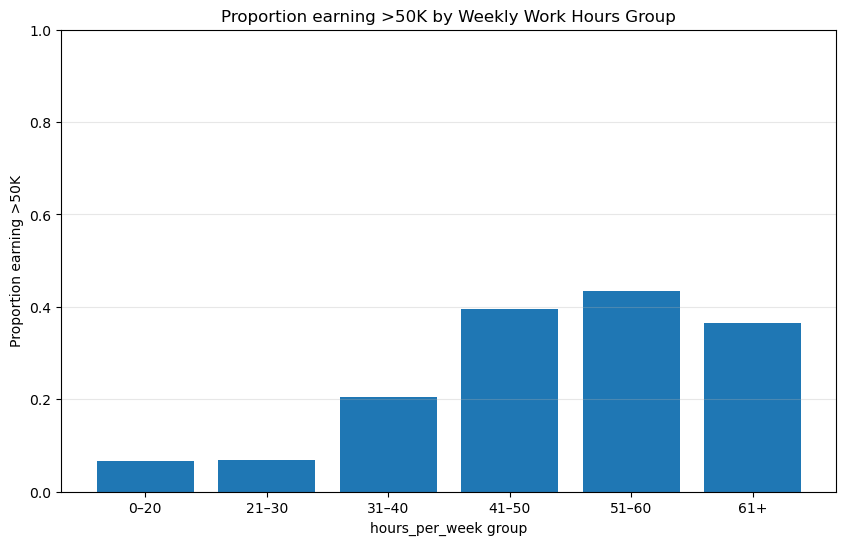

In [20]:
tmp = adult_df[["hours_per_week", "income"]].dropna().copy()
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["0–20", "21–30", "31–40", "41–50", "51–60", "61+"]
tmp["hours_group"] = pd.cut(tmp["hours_per_week"], bins=bins, labels=labels, right=True)

rate = tmp.groupby("hours_group")["income"].apply(lambda s: (s == ">50K").mean())

plt.figure(figsize=(10, 6))
plt.bar(rate.index.astype(str), rate.values)
plt.ylim(0, 1)
plt.title("Proportion earning >50K by Weekly Work Hours Group")
plt.xlabel("hours_per_week group")
plt.ylabel("Proportion earning >50K")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
3) Work Hours Hypotheses:-
The box plot and grouped bar chart show that individuals who work more hours per week tend to have a higher proportion of earners above $50,000.
Full-time and overtime work categories have significantly higher income rates compared to part-time workers.
Conclusion: hours_per_week is positively associated with income and serves as an important indicator of earning potential.


## 4) Occupation and Workclass Hypotheses


In [ ]:
Occupation vs Income
H0: Income category is independent of occupation.
H1: Income category depends on occupation.
Why: Different occupations require varying skill levels, education, and experience, and they typically offer different salary ranges. As a result,
some occupations are more likely to be associated with higher income levels than others.

In [55]:
# Quick cross-tab example (Occupation vs Income) - not a statistical test yet
pd.crosstab(adult_df["occupation"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
occupation,,
?,0.896365,0.103635
Adm-clerical,0.865517,0.134483
Armed-Forces,0.888889,0.111111
Craft-repair,0.773359,0.226641
Exec-managerial,0.515986,0.484014
Farming-fishing,0.884306,0.115694
Handlers-cleaners,0.937226,0.062774
Machine-op-inspct,0.875125,0.124875
Other-service,0.958422,0.041578


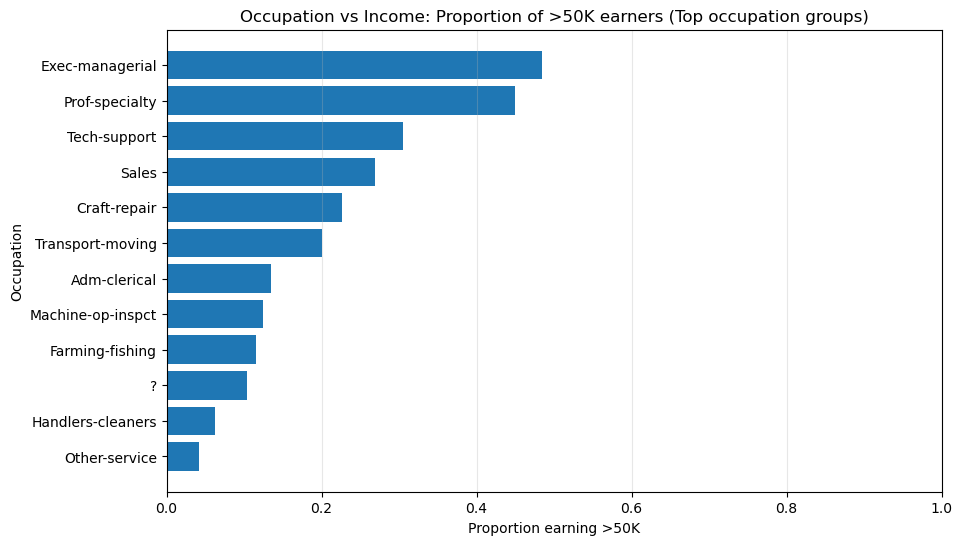

In [21]:
plot_high_income_rate_by_category(
    adult_df, "occupation", min_count=100, top_n=12,
    title="Occupation vs Income: Proportion of >50K earners (Top occupation groups)"
)


In [ ]:
Workclass vs Income
H0: Income category is independent of workclass.
H1: Income category depends on workclass.
Why: Different work classes—such as private sector, government, and self-employed—often have different pay structures, job stability, and growth
opportunities, which may lead to noticeable differences in income levels.    

In [56]:
# Quick cross-tab example (workclass vs Income) - not a statistical test yet
pd.crosstab(adult_df["workclass"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
workclass,,
?,0.895969,0.104031
Federal-gov,0.613542,0.386458
Local-gov,0.705208,0.294792
Never-worked,1.000000,0.000000
Private,0.781327,0.218673
Self-emp-inc,0.442652,0.557348
Self-emp-not-inc,0.715073,0.284927
State-gov,0.728043,0.271957
Without-pay,1.000000,0.000000


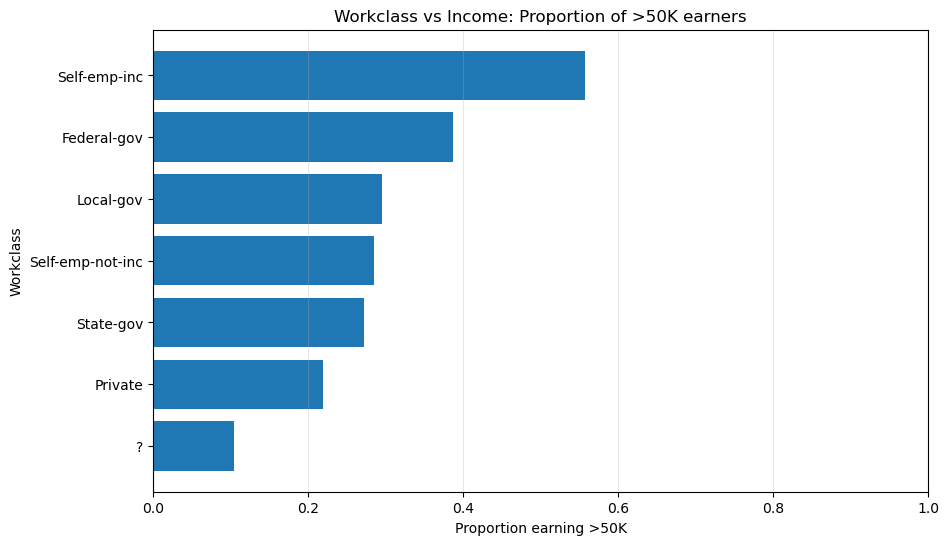

In [22]:
plot_high_income_rate_by_category(
    adult_df, "workclass", min_count=100, top_n=10,
    title="Workclass vs Income: Proportion of >50K earners"
)


In [ ]:
4) Occupation and Workclass Hypotheses:-
The occupation and workclass plots highlight substantial differences in income across job types. Professional and managerial occupations show
the highest proportion of high earners, while service and manual roles show lower rates. Income also varies across workclass categories,
indicating that employment type plays a role in earnings.
Conclusion: Occupation and workclass are strong categorical predictors and capture meaningful income differences across job roles.


## 5) Marital Status and Relationship Hypotheses


In [ ]:
Marital Status vs Income
H0: Income category is independent of marital status.
H1: Income category depends on marital status.
Why: Household/earning patterns often correlate with marital status.

In [58]:
# Quick cross-tab example (Marital Status vs Income) - not a statistical test yet
pd.crosstab(adult_df["marital_status"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
marital_status,,
Divorced,0.895791,0.104209
Married-AF-spouse,0.565217,0.434783
Married-civ-spouse,0.553152,0.446848
Married-spouse-absent,0.918660,0.081340
Never-married,0.954039,0.045961
Separated,0.935610,0.064390
Widowed,0.914401,0.085599


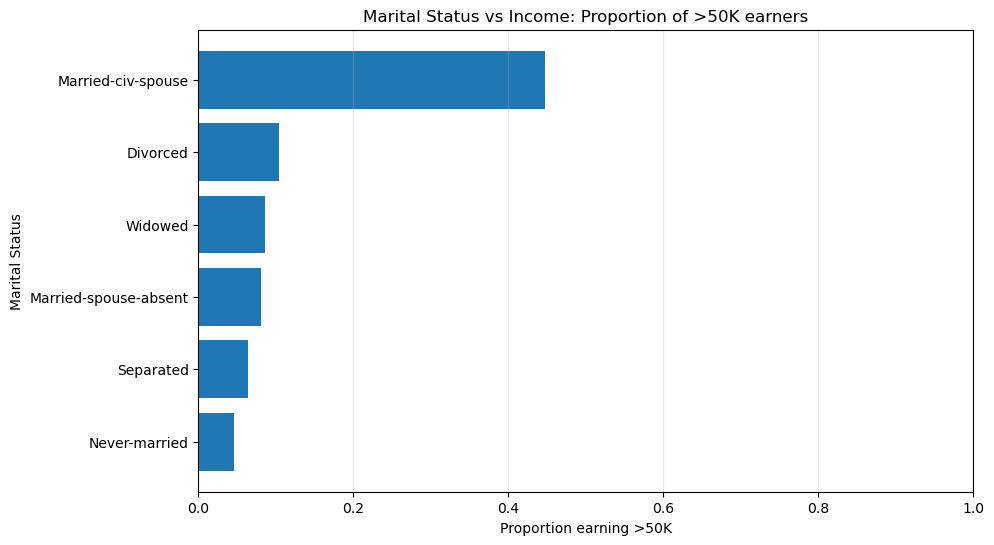

In [23]:
plot_high_income_rate_by_category(
    adult_df, "marital_status", min_count=100, top_n=10,
    title="Marital Status vs Income: Proportion of >50K earners"
)


In [ ]:
H0: Income category is independent of relationship status.
H1: Income category depends on relationship status.
Why:Relationship status (such as married, never married, or not-in-family) often correlates with household structure, work stability, and career stage,
which may influence earning potential and increase the likelihood of higher income.    

In [59]:
# Quick cross-tab example (Relationship vs Income) - not a statistical test yet
pd.crosstab(adult_df["relationship"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
relationship,,
Husband,0.551429,0.448571
Not-in-family,0.896930,0.103070
Other-relative,0.962283,0.037717
Own-child,0.986780,0.013220
Unmarried,0.936738,0.063262
Wife,0.524872,0.475128


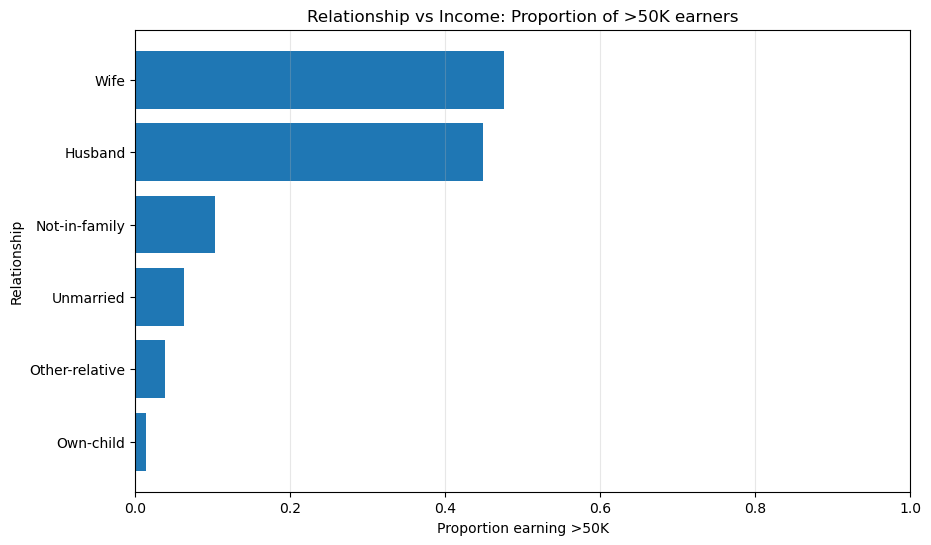

In [24]:
plot_high_income_rate_by_category(
    adult_df, "relationship", min_count=100, top_n=10,
    title="Relationship vs Income: Proportion of >50K earners"
)


In [ ]:
5) Marital Status and Relationship Hypotheses:-
The marital status and relationship plots indicate that married individuals, particularly those categorized as “Married-civ-spouse,
”have a higher proportion of earners above $50,000. Relationship roles also show noticeable income differences, reflecting variations
in household structure and employment stability.
Conclusion: Marital status and relationship features are strongly associated with income and provide useful socio-economic context.


## 6) Capital Gain and Capital Loss Hypotheses


C:\Users\sndrp\AppData\Local\Temp\ipykernel_28852\1722329919.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)


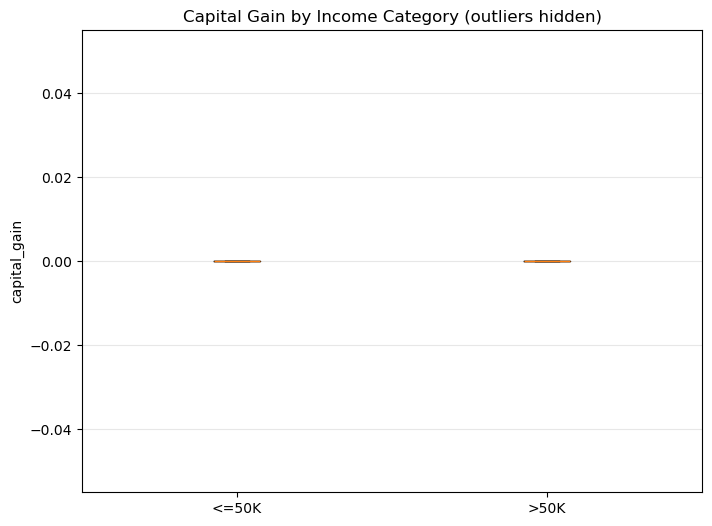

In [25]:
tmp = adult_df[["capital_gain", "income"]].dropna().copy()

plt.figure(figsize=(8, 6))
data = [tmp.loc[tmp["income"] == "<=50K", "capital_gain"],
        tmp.loc[tmp["income"] == ">50K", "capital_gain"]]
plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)
plt.title("Capital Gain by Income Category (outliers hidden)")
plt.ylabel("capital_gain")
plt.grid(axis="y", alpha=0.3)
plt.show()


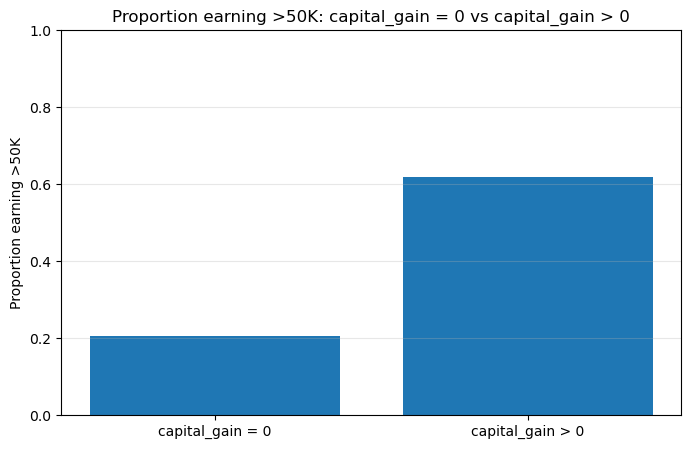

In [26]:
tmp = adult_df[["capital_gain", "income"]].dropna().copy()
tmp["cap_gain_flag"] = np.where(tmp["capital_gain"] > 0, "capital_gain > 0", "capital_gain = 0")
rate = tmp.groupby("cap_gain_flag")["income"].apply(lambda s: (s == ">50K").mean())

plt.figure(figsize=(8, 5))
plt.bar(rate.index, rate.values)
plt.ylim(0, 1)
plt.title("Proportion earning >50K: capital_gain = 0 vs capital_gain > 0")
plt.ylabel("Proportion earning >50K")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
6) Capital Gain and Capital Loss Hypotheses:-
The capital gain plots clearly show that individuals with any non-zero capital gain are far more likely to earn above $50,000. The difference
between those with zero and non-zero capital gains is one of the strongest separations observed across all hypotheses.
Conclusion: capital_gain is one of the most powerful indicators of high income, although its skewed nature will
require careful handling during modeling.


## 7) Demographic and Fairness Hypotheses


In [ ]:
 Sex vs Income
H0: Income category is independent of sex.
H1: Income category depends on sex.
Why: Income differences across gender groups may exist.

In [52]:
# Quick cross-tab example (Sex vs Income) - not a statistical test yet
pd.crosstab(adult_df["sex"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
sex,,
Female,0.890539,0.109461
Male,0.694263,0.305737


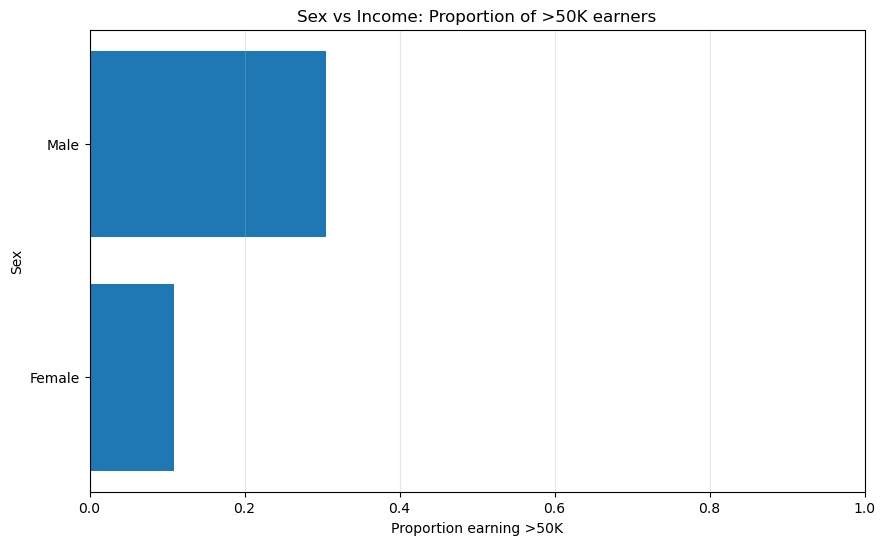

In [27]:
plot_high_income_rate_by_category(
    adult_df, "sex", min_count=50, top_n=10,
    title="Sex vs Income: Proportion of >50K earners"
)


In [ ]:
race vs Income
H0: Income category is independent of race.
H1: Income category depends on race.
Why:Race may be associated with differences in access to education, job opportunities, and economic resources, which can influence income levels.    

In [61]:
# Quick cross-tab example (race vs Income) - not a statistical test yet
pd.crosstab(adult_df["race"], adult_df["income"], normalize="index").head(10)

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,0.884244,0.115756
Asian-Pac-Islander,0.734360,0.265640
Black,0.876120,0.123880
Other,0.907749,0.092251
White,0.744140,0.255860


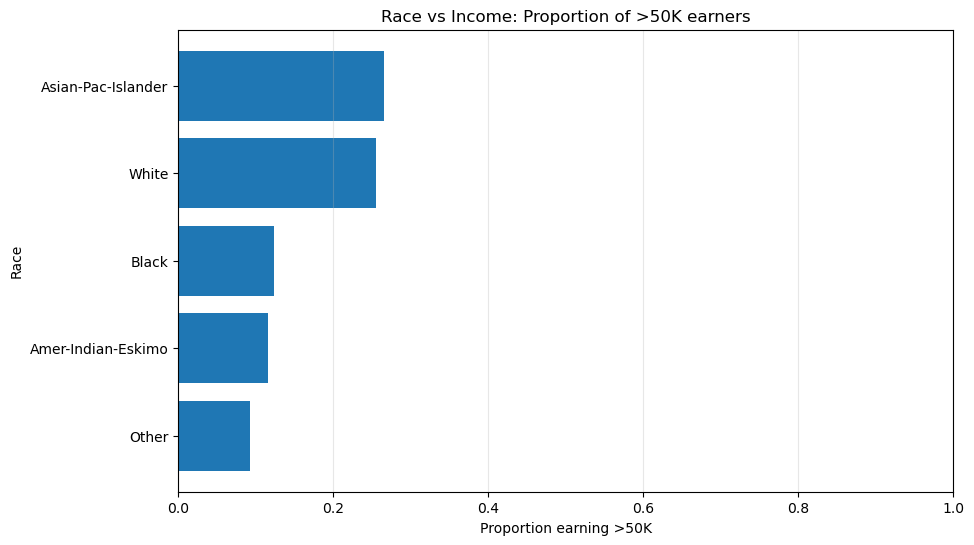

In [28]:
plot_high_income_rate_by_category(
    adult_df, "race", min_count=50, top_n=10,
    title="Race vs Income: Proportion of >50K earners"
)


In [ ]:
7) Demographic and Fairness Hypotheses:-
The plots for sex and race show that income distribution differs across demographic groups. Some groups consistently show higher proportions
of earners above $50,000. However, these differences likely reflect broader societal and historical factors rather than individual ability.
Conclusion: Demographic variables reveal disparities in income distribution and must be interpreted cautiously, with attention to fairness 
and ethical considerations in modeling.


## 8) Census Weight (fnlwgt) Hypotheses


C:\Users\sndrp\AppData\Local\Temp\ipykernel_28852\1084609226.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)


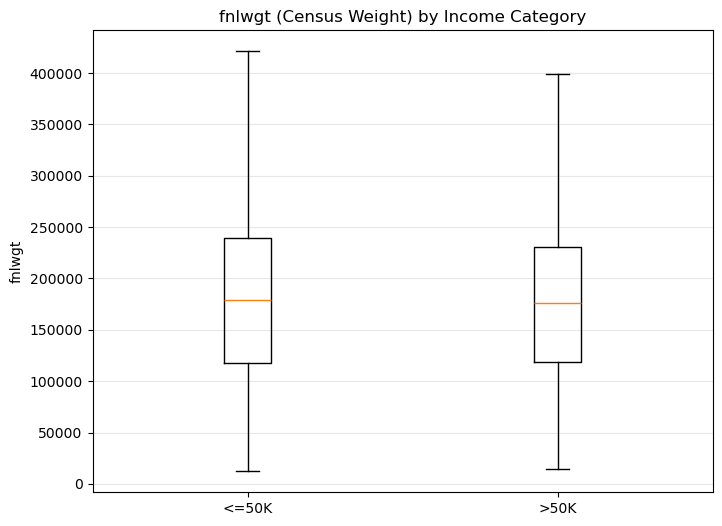

In [29]:
tmp = adult_df[["fnlwgt", "income"]].dropna().copy()

plt.figure(figsize=(8, 6))
data = [tmp.loc[tmp["income"] == "<=50K", "fnlwgt"],
        tmp.loc[tmp["income"] == ">50K", "fnlwgt"]]
plt.boxplot(data, labels=["<=50K", ">50K"], showfliers=False)
plt.title("fnlwgt (Census Weight) by Income Category")
plt.ylabel("fnlwgt")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [38]:
adult_df.groupby("income")["fnlwgt"].agg(["count", "mean", "median", "min", "max"]).round(2)


,count,mean,median,min,max
income,,,,,
<=50K,24720,190340.87,179465.0,12285,1484705
>50K,7841,188005.00,176101.0,14878,1226583


In [ ]:
8) Census Weight (fnlwgt) Hypotheses:-
Looking at the box plot and the summary stats for fnlwgt, there’s just no clear split between the income groups. That makes sense—fnlwgt is
really just the sampling weight in the census, not something about the person. So, it doesn’t seem to connect much with income.
Conclusion: fnlwgt isn’t a strong predictor for income and probably isn’t as useful as other features.

In [ ]:
overall conclusion:-
Education shows a clear upward trend in >50K rate as education_num increases.
Age shows higher >50K rates in mid-career groups.
Hours-per-week shows higher >50K rates for full-time/longer hours.
Capital gain > 0 is one of the strongest signals for >50K.
Sex/race differences exist and must be discussed ethically.
fnlwgt appears less directly tied to income compared to other features.

these hypothesis plots confirm that education, age, work hours, occupation, marital status, and capital gain are strongly
associated with income. Capital gain and education emerge as especially influential features, while demographic variables highlight important
fairness considerations. Census weight shows minimal direct relevance. These insights provide a strong foundation for feature selection and 
model building in the next stages of the machine learning workflow.    